In [ ]:
# Download and extract the dataset
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces --unzip -p ./real_vs_fake_faces

# Verify that the dataset is downloaded
!ls ./real_vs_fake_faces

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.74G/3.75G [00:42<00:00, 130MB/s]
100% 3.75G/3.75G [00:43<00:00, 93.0MB/s]
real_vs_fake  test.csv	train.csv  valid.csv


In [1]:
# 1. Import Libraries
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.models import resnet50
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# 2. Data Augmentation and Transformations
def create_transformations():
    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
        transforms.RandomRotation(20),
        transforms.RandomPerspective(distortion_scale=0.3, p=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return train_transforms, test_transforms

In [3]:
# 3. Data Loading
def load_datasets(root_dir, train_transforms, test_transforms):
    train_dataset = datasets.ImageFolder(
        os.path.join(root_dir, 'train'),
        transform=train_transforms
    )
    val_dataset = datasets.ImageFolder(
        os.path.join(root_dir, 'valid'),
        transform=test_transforms
    )
    test_dataset = datasets.ImageFolder(
        os.path.join(root_dir, 'test'),
        transform=test_transforms
    )

    return train_dataset, val_dataset, test_dataset

def create_data_loaders(datasets, batch_size=32):
    train_loader = DataLoader(datasets[0], batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(datasets[1], batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(datasets[2], batch_size=batch_size, shuffle=False)

    return {
        'train': train_loader,
        'val': val_loader,
        'test': test_loader
    }

def print_dataset_stats(datasets):
    names = ['Train', 'Validation', 'Test']
    for name, dataset in zip(names, datasets):
        print(f"{name} Dataset:")
        print(f"Total Images: {len(dataset)}")
        print(f"Class Distribution: {dataset.class_to_idx}")
        print("Class Counts:",
              {dataset.classes[i]: count for i, count in
               enumerate(np.bincount(dataset.targets))})
        print()

In [ ]:
# 4. Model Architecture
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet50Classifier, self).__init__()
        self.resnet = resnet50(pretrained=True)
        self.resnet.fc = nn.Sequential(
            nn.Linear(self.resnet.fc.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

In [5]:
# 5. Custom Loss Functions
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return torch.mean(F_loss)

def visualize_random_images(model, val_loader, device, num_images=10):
    model.eval()
    class_names = val_loader.dataset.classes

    # Select random images
    indices = np.random.randint(0, len(val_loader.dataset), num_images)

    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(indices):
        image, true_label = val_loader.dataset[idx]
        image = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image)
            _, pred_label = torch.max(output, 1)

        plt.subplot(2, 5, i+1)
        plt.imshow(image.cpu().squeeze().permute(1, 2, 0).numpy())
        plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# 6. Plot Functions
def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    # Plot Training Accuracy and Loss
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Training Loss")
    plt.plot(epochs, history["train_acc"], label="Training Accuracy")
    plt.title("Training Accuracy and Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss / Accuracy")
    plt.legend()

    # Plot Validation Accuracy and Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.title("Validation Accuracy and Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss / Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

Train Dataset:
Total Images: 100000
Class Distribution: {'fake': 0, 'real': 1}
Class Counts: {'fake': 50000, 'real': 50000}

Validation Dataset:
Total Images: 20000
Class Distribution: {'fake': 0, 'real': 1}
Class Counts: {'fake': 10000, 'real': 10000}

Test Dataset:
Total Images: 20000
Class Distribution: {'fake': 0, 'real': 1}
Class Counts: {'fake': 10000, 'real': 10000}



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9831933..1.9749122].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781512..2.1804092].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9306722..2.4831376].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.0947855].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..

Epoch 1/6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


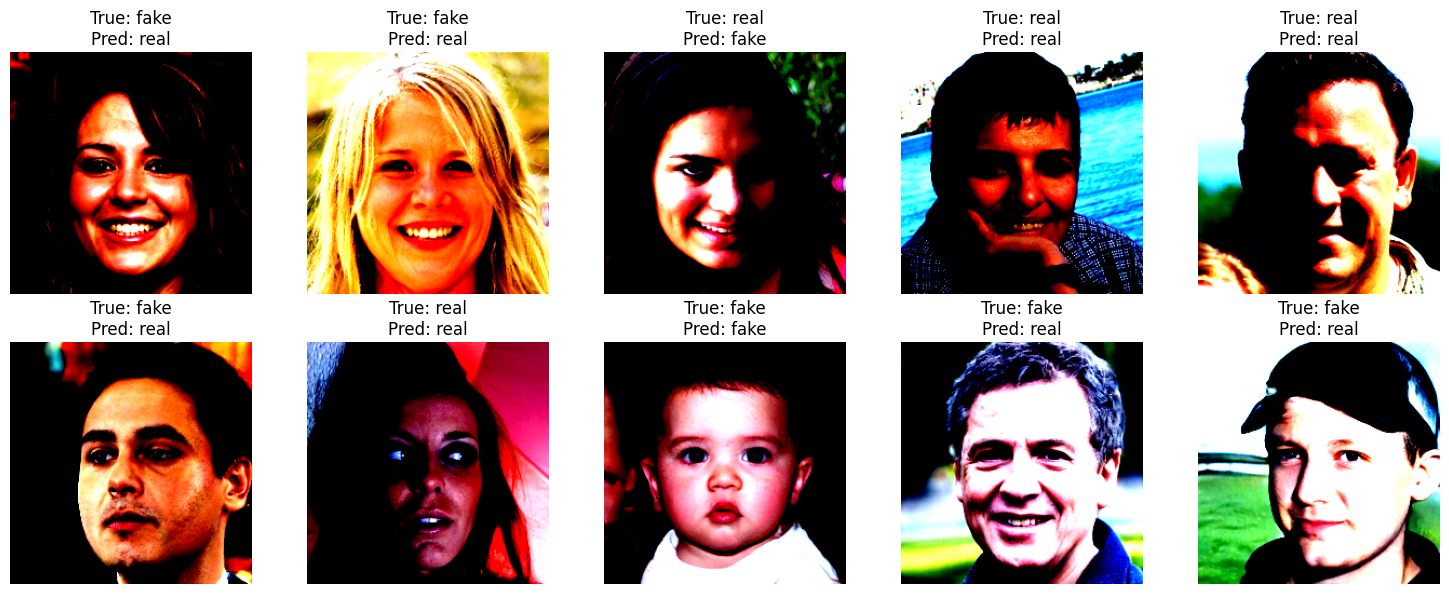

train Loss: 0.0497 Accuracy: 0.9241


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.2146587].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.5005665].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4482791].
C

val Loss: 0.0377 Accuracy: 0.9430
Epoch 2/6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8606442..2.64].


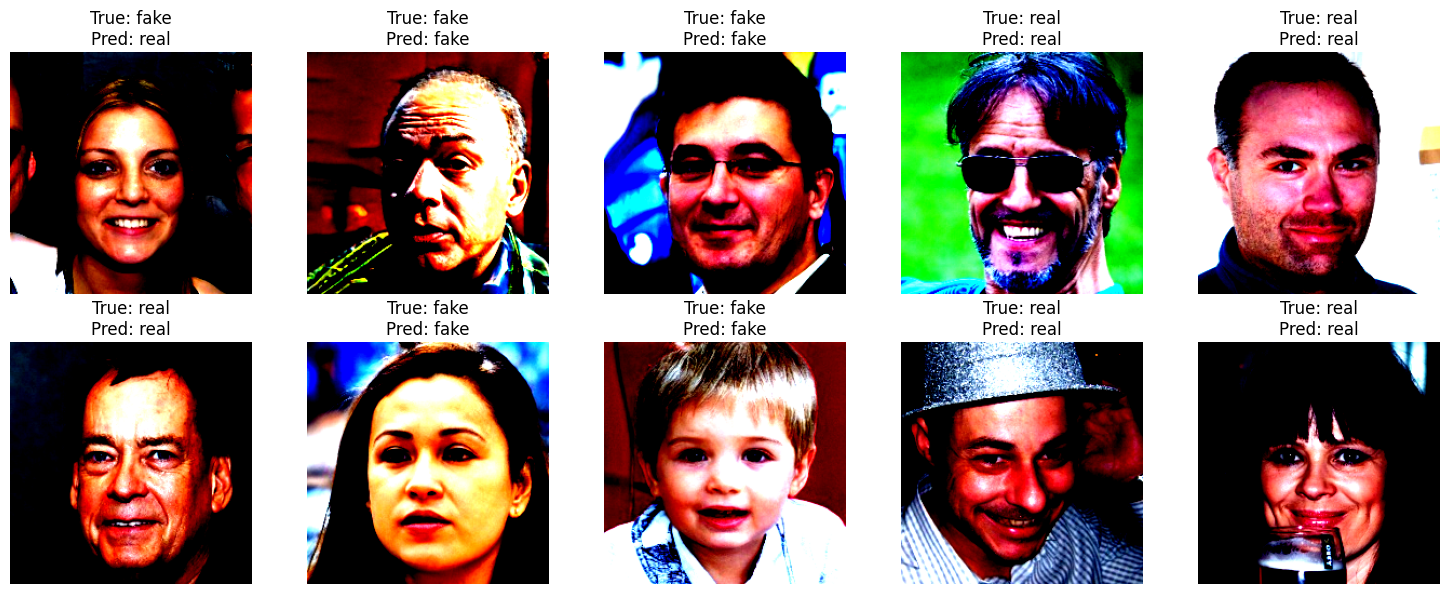

train Loss: 0.0255 Accuracy: 0.9644


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9733893].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.2146587].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9481792..2.3959913].
Cl

val Loss: 0.0119 Accuracy: 0.9851
Epoch 3/6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9481792..1.923538].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


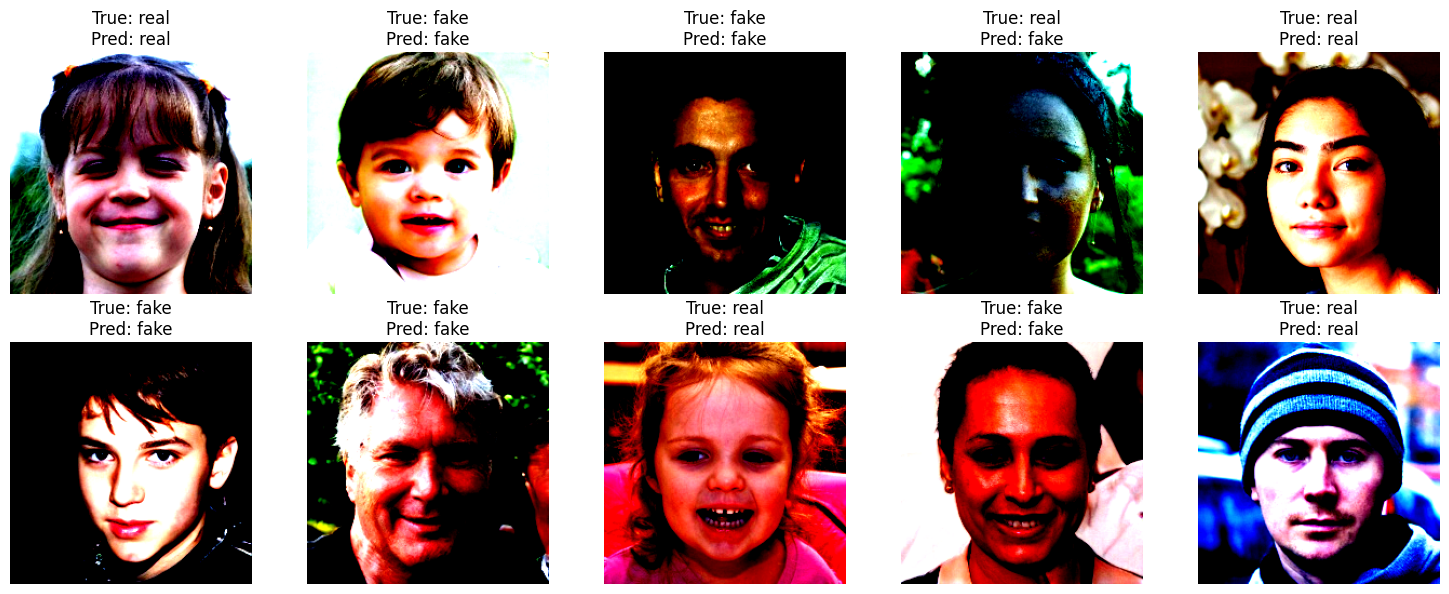

train Loss: 0.0189 Accuracy: 0.9746


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.2317834].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].


val Loss: 0.0066 Accuracy: 0.9910
Epoch 4/6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1632845].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.4134207].


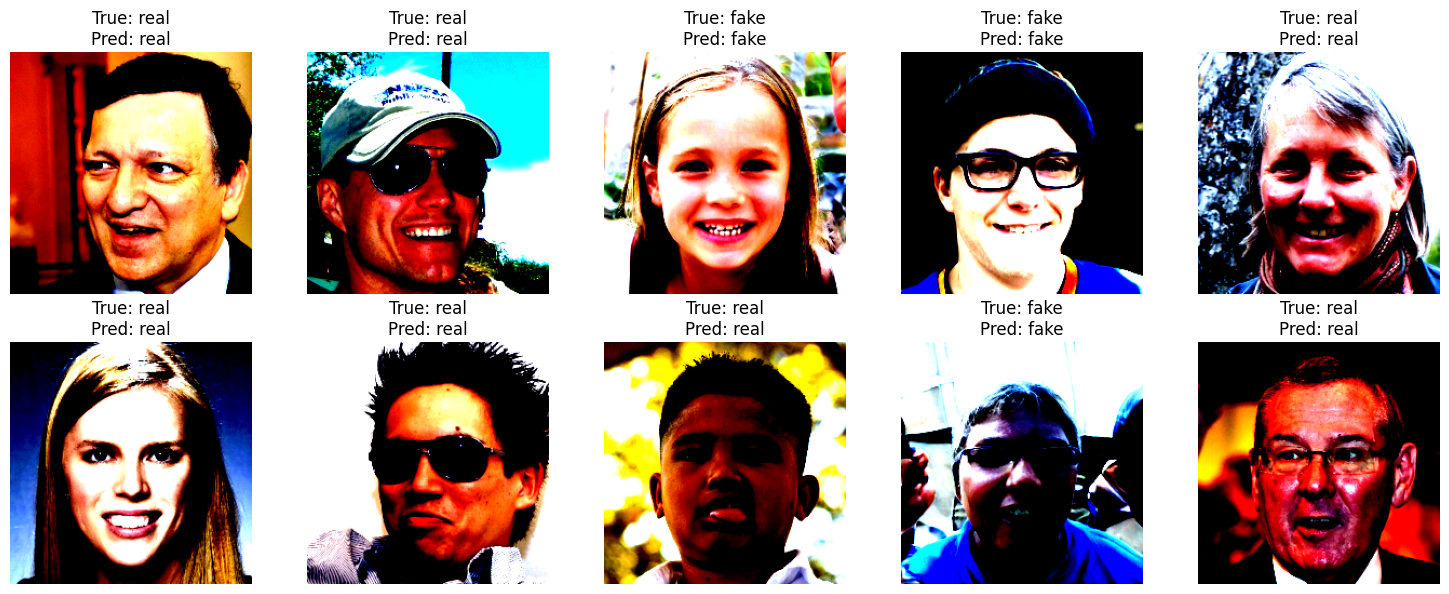

train Loss: 0.0164 Accuracy: 0.9780


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.2914162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7030813..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781512..2.64]

val Loss: 0.0076 Accuracy: 0.9899
Epoch 5/6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..1.9406626].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].


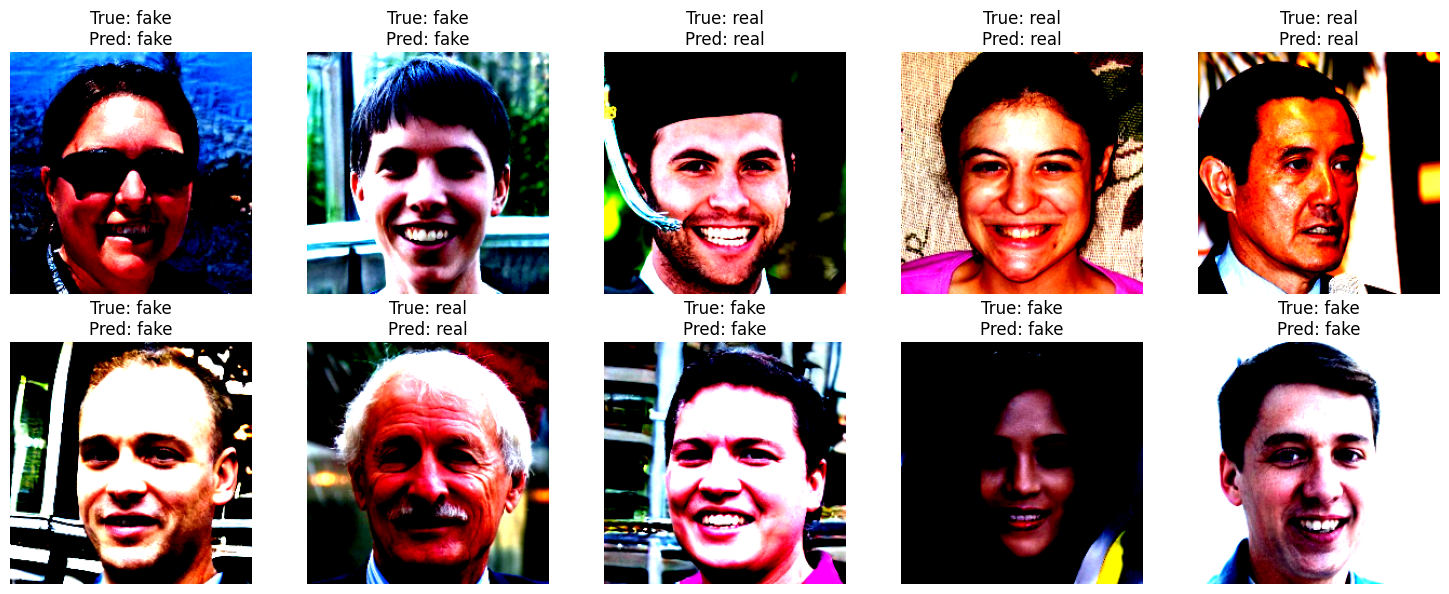

train Loss: 0.0143 Accuracy: 0.9812


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2317834].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.343704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.3785625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.2565577].


val Loss: 0.0048 Accuracy: 0.9939
Epoch 6/6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2914162].


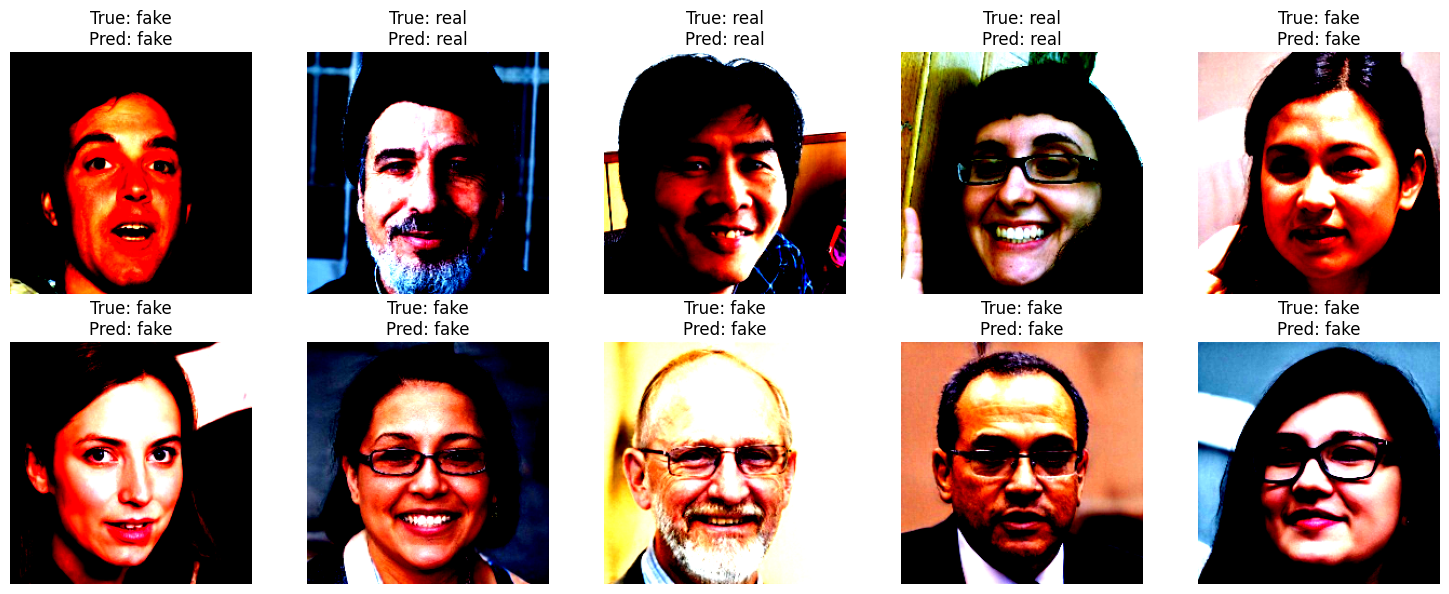

train Loss: 0.0128 Accuracy: 0.9829
val Loss: 0.0128 Accuracy: 0.9819


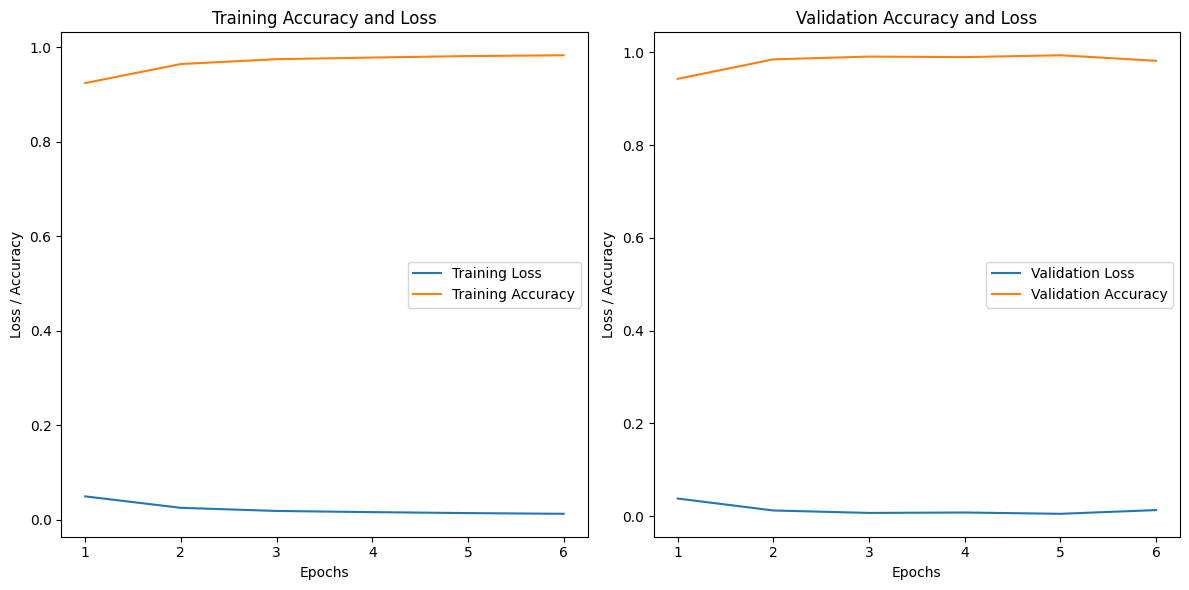

In [ ]:
# 7. Training Loop
def train_model(model, dataloaders, criterion, optimizer, scheduler, device, num_epochs=6):
    # Track metrics
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }
    best_val_acc = 0.0
    best_model_wts = model.state_dict()

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        # Visualization of random validation images
        visualize_random_images(model, dataloaders['val'], device)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            with torch.set_grad_enabled(phase == 'train'):
                for inputs, labels in dataloaders[phase]:
                    inputs, labels = inputs.to(device), labels.to(device)

                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    _, preds = torch.max(outputs, 1)
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f"{phase} Loss: {epoch_loss:.4f} Accuracy: {epoch_acc:.4f}")

            if phase == 'train':
                history["train_loss"].append(epoch_loss)
                history["train_acc"].append(epoch_acc.item())
            else:
                history["val_loss"].append(epoch_loss)
                history["val_acc"].append(epoch_acc.item())
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = model.state_dict()

        scheduler.step(epoch_loss)

    model.load_state_dict(best_model_wts)
    return model, history

def main():
    # Configuration
    root_dir = './real_vs_fake_faces/real_vs_fake/real-vs-fake'
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Transformations
    train_transforms, test_transforms = create_transformations()

    # Datasets
    datasets = load_datasets(root_dir, train_transforms, test_transforms)
    print_dataset_stats(datasets)

    # Data Loaders
    dataloaders = create_data_loaders(datasets)

    # Model Setup
    model = ResNet50Classifier(num_classes=2).to(device)
    criterion = FocalLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    # Training
    trained_model, history = train_model(model, dataloaders, criterion, optimizer, scheduler, device)
    torch.save(model.state_dict(), "ResNet50_only_classifier.pth")

    # Plot Training History
    plot_training_history(history)

    # Evaluation
    # evaluate_model(trained_model, dataloaders['test'], device)

if __name__ == '__main__':
    main()

C:\Users\Nihal Pratap\AppData\Local\Temp\ipykernel_39884\2330746356.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ResNet50_only_cla

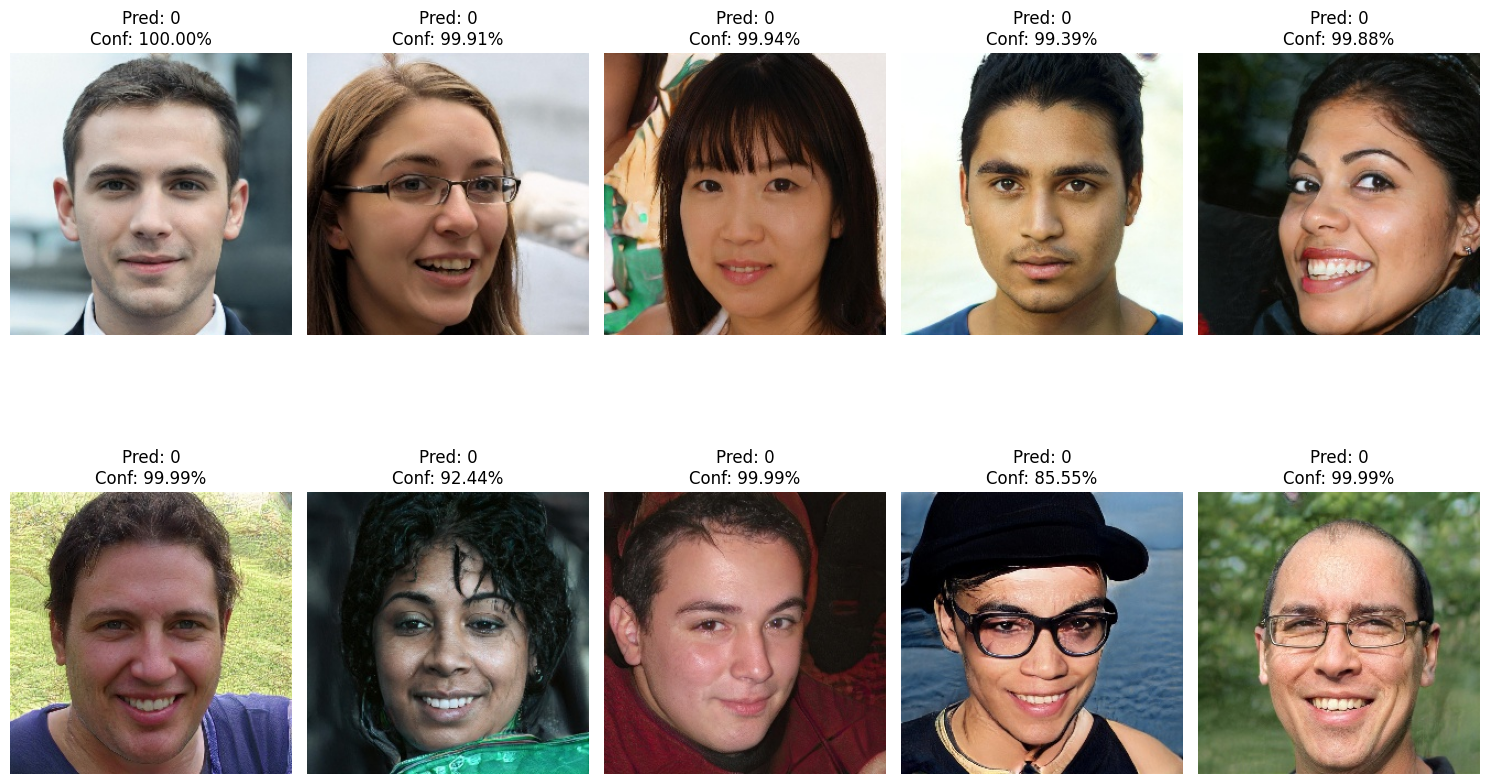


--- Prediction Report ---
Image: HHZ2XB6ICK.jpg
Predicted Class: Fake
Confidence: 100.00%

Image: RTS92BGVQ8.jpg
Predicted Class: Fake
Confidence: 99.91%

Image: 04GBOSL1AD.jpg
Predicted Class: Fake
Confidence: 99.94%

Image: ZD7G269924.jpg
Predicted Class: Fake
Confidence: 99.39%

Image: TL8D99YN1P.jpg
Predicted Class: Fake
Confidence: 99.88%

Image: 42JGIBG7G5.jpg
Predicted Class: Fake
Confidence: 99.99%

Image: 7CBS9F90L7.jpg
Predicted Class: Fake
Confidence: 92.44%

Image: PC7IDL0WUG.jpg
Predicted Class: Fake
Confidence: 99.99%

Image: L00IBRMJ0S.jpg
Predicted Class: Fake
Confidence: 85.55%

Image: 5IQZHGGSLO.jpg
Predicted Class: Fake
Confidence: 99.99%



In [ ]:
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

def predict_single_image(model, image_path, device, transform=None):
    # Use default transform if not provided
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    # Load and preprocess the image
    model.eval()
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Perform prediction
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][predicted_class].item()

    return predicted_class, confidence, image

def predict_directory(model, directory_path, device, transform=None, top_n=10):
    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.gif']
    image_files = [
        os.path.join(directory_path, f)
        for f in os.listdir(directory_path)
        if os.path.splitext(f)[1].lower() in image_extensions
    ]

    # Randomly select top_n images
    np.random.shuffle(image_files)
    selected_images = image_files[:top_n]

    # Prediction results
    prediction_results = []

    # Create a figure for visualization
    plt.figure(figsize=(15, 10))

    # Prediction loop
    for i, image_path in enumerate(selected_images, 1):
        try:
            # Predict single image
            predicted_class, confidence, image = predict_single_image(
                model, image_path, device, transform
            )

            # Store prediction result
            prediction_results.append({
                'image_path': image_path,
                'predicted_class': predicted_class,
                'confidence': confidence
            })

            # Visualization
            plt.subplot(2, 5, i)
            plt.imshow(np.array(image))
            plt.title(f"Pred: {predicted_class}\nConf: {confidence:.2%}")
            plt.axis('off')

        except Exception as e:
            print(f"Error processing {image_path}: {e}")

    plt.tight_layout()
    plt.show()

    return prediction_results

def generate_detailed_report(prediction_results, class_names):
    print("\n--- Prediction Report ---")
    for result in prediction_results:
        print(f"Image: {os.path.basename(result['image_path'])}")
        print(f"Predicted Class: {class_names[result['predicted_class']]}")
        print(f"Confidence: {result['confidence']:.2%}\n")

def main():
    # Model and device setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ResNet50Classifier(num_classes=2).to(device)
    model.load_state_dict(torch.load('ResNet50_only_classifier.pth'))
    model.eval()

    # Transformation
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # Class names
    class_names = ['Fake', 'Real']  # Adjust based on your dataset

    # Directory prediction example
    directory_path = './real_vs_fake_faces/real_vs_fake/real-vs-fake/test/fake'
    prediction_results = predict_directory(
        model, directory_path, device, transform, top_n=10
    )

    # Generate detailed report
    generate_detailed_report(prediction_results, class_names)

if __name__ == '__main__':
    main()